In [13]:
import cv2
import numpy as np
import torch
import json
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor

# --- CONFIG ---
MODEL_PATH = "game-state/checkpoint"  # Path to VideoMAE checkpoint folder
VIDEO_PATH = "input_video.mp4"        # Input video path
CLIP_LENGTH = 16                   # Number of frames per clip
FRAME_SIZE = (224, 224)               # Size for VideoMAE input
OUTPUT_LABELS_JSON = "clip_labels.json"  # Save clip labels here

# Local fine-tuned checkpoint
model = VideoMAEForVideoClassification.from_pretrained(r"game-state\game-state\3-states\checkpoint")

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-huge-finetuned-kinetics")


# Load model and processor
model.eval()

def extract_clips(video_path, clip_length):
    cap = cv2.VideoCapture(video_path)
    clips = []
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            if frames:
                clips.append(frames)
            break
        frame = cv2.resize(frame, FRAME_SIZE)
        frame = frame[:, :, ::-1]  # BGR to RGB
        frames.append(frame.astype(np.float32) / 255.0)

        if len(frames) == clip_length:
            clips.append(frames)
            frames = []

    cap.release()
    return clips

def classify_clip(frames):
    frames_np = np.array(frames)
    frames_np = frames_np.transpose(0, 3, 1, 2)  # (T, H, W, C) -> (T, C, H, W)
    video = list(frames_np)
    inputs = processor(video, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred_idx = logits.argmax(-1).item()
        label = model.config.id2label[pred_idx]
    return label

def main():
    clips = extract_clips(VIDEO_PATH, CLIP_LENGTH)
    print(f"Extracted {len(clips)} clips from video.")

    clip_labels = {}
    for i, clip_frames in enumerate(clips):
        if len(clip_frames) != CLIP_LENGTH:
            print(f"Skipping Clip {i} — only {len(clip_frames)} frames (expected {CLIP_LENGTH})")
            continue

        label = classify_clip(clip_frames)
        print(f"Clip {i}: {label}")
        clip_labels[i] = label

    with open(OUTPUT_LABELS_JSON, "w") as f:
        json.dump(clip_labels, f, indent=2)
    print(f"Saved clip labels to {OUTPUT_LABELS_JSON}")


if __name__ == "__main__":
    main()

    
    
    

Extracted 28 clips from video.
Clip 0: play
Clip 1: play
Clip 2: play
Clip 3: play
Clip 4: play
Clip 5: play
Clip 6: play
Clip 7: play
Clip 8: play
Clip 9: play
Clip 10: play
Clip 11: play
Clip 12: play
Clip 13: play
Clip 14: play
Clip 15: play
Clip 16: play
Clip 17: play
Clip 18: play
Clip 19: play
Clip 20: play
Clip 21: play
Clip 22: play
Clip 23: play
Clip 24: play
Clip 25: play
Clip 26: play
Skipping Clip 27 — only 13 frames (expected 16)
Saved clip labels to clip_labels.json


In [16]:
import cv2
import json
from ultralytics import YOLO

# --- CONFIG ---
YOLO_MODEL_PATH = r"C:\Users\Nitro v15\Desktop\volly high\action_detection\action_detection\6_class\1\weights\best.pt"
VIDEO_PATH = "input_video.mp4"
CLIP_LENGTH = 30
CLIP_LABELS_JSON = "clip_labels.json"
CONF_THRESHOLD = 0.3
OUTPUT_VIDEO_PATH = "output_annotated_video.mp4"

model = YOLO(YOLO_MODEL_PATH)

def visualize(frame, results):
    for result in results:
        boxes = result.boxes
        masks = result.masks
        for i, box in enumerate(boxes):
            cls_id = int(box.cls.item())
            conf = box.conf.item()
            if conf < CONF_THRESHOLD:
                continue
            label = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box + label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

            # Overlay ball mask in red
            if masks and masks.data is not None and label.lower() == "ball":
                mask = masks.data[i].cpu().numpy()
                mask = (mask > 0.5).astype('uint8') * 255
                colored_mask = cv2.merge([mask*0, mask*0, mask])  # Red channel only
                frame = cv2.addWeighted(frame, 1.0, colored_mask, 0.5, 0)
    return frame

def main():
    with open(CLIP_LABELS_JSON, "r") as f:
        clip_labels = json.load(f)

    cap = cv2.VideoCapture(VIDEO_PATH)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

    frame_count = 0
    clip_index = 0
    clip_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        clip_frames.append(frame)
        frame_count += 1

        if frame_count % CLIP_LENGTH == 0:
            label = clip_labels.get(str(clip_index), "no-play")

            if label in ["play", "service"]:
                for f in clip_frames:
                    results = model(f, task="segment")
                    f = visualize(f, results)

                    # Overlay VideoMAE clip label at top-left corner
                    cv2.putText(f, f"Clip Label: {label}", (20, 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

                    out.write(f)

                    cv2.imshow("Volleyball Analysis", f)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        cap.release()
                        out.release()
                        cv2.destroyAllWindows()
                        return
            else:
                print(f"Skipping clip {clip_index} labeled '{label}'")
                # Save original frames without YOLO overlay but with clip label
                for f in clip_frames:
                    cv2.putText(f, f"Clip Label: {label}", (20, 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                    out.write(f)

            clip_frames = []
            clip_index += 1

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Saved annotated video to {OUTPUT_VIDEO_PATH}")

if __name__ == "__main__":
    main()

    


0: 576x1024 (no detections), 202.8ms
Speed: 11.3ms preprocess, 202.8ms inference, 6.6ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 172.0ms
Speed: 7.5ms preprocess, 172.0ms inference, 1.0ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 160.3ms
Speed: 8.1ms preprocess, 160.3ms inference, 1.1ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 171.1ms
Speed: 7.2ms preprocess, 171.1ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 167.2ms
Speed: 7.6ms preprocess, 167.2ms inference, 1.5ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 183.2ms
Speed: 7.9ms preprocess, 183.2ms inference, 1.5ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 193.9ms
Speed: 10.2ms preprocess, 193.9ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 211.8ms
S

In [18]:
import cv2
import json
import csv
from ultralytics import YOLO

# --- CONFIG ---
YOLO_MODEL_PATH = r"C:\Users\Nitro v15\Desktop\volly high\action_detection\action_detection\6_class\1\weights\best.pt"
VIDEO_PATH = "input_video.mp4"
CLIP_LENGTH = 30
CLIP_LABELS_JSON = "clip_labels.json"
CONF_THRESHOLD = 0.3
OUTPUT_VIDEO_PATH = "output_annotated_video.mp4"
CSV_OUTPUT_PATH = "volleyball_clip_stats.csv"

model = YOLO(YOLO_MODEL_PATH)

def visualize(frame, results):
    for result in results:
        boxes = result.boxes
        masks = result.masks
        for i, box in enumerate(boxes):
            cls_id = int(box.cls.item())
            conf = box.conf.item()
            if conf < CONF_THRESHOLD:
                continue
            label = model.names[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box + label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

            # Overlay ball mask in red
            if masks and masks.data is not None and label.lower() == "ball":
                mask = masks.data[i].cpu().numpy()
                mask = (mask > 0.5).astype('uint8') * 255
                colored_mask = cv2.merge([mask*0, mask*0, mask])  # Red channel only
                frame = cv2.addWeighted(frame, 1.0, colored_mask, 0.5, 0)
    return frame

def main():
    with open(CLIP_LABELS_JSON, "r") as f:
        clip_labels = json.load(f)

    cap = cv2.VideoCapture(VIDEO_PATH)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

    frame_count = 0
    clip_index = 0
    clip_frames = []

    stats = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        clip_frames.append(frame)
        frame_count += 1

        if frame_count % CLIP_LENGTH == 0:
            label = clip_labels.get(str(clip_index), "no-play").lower()

            # Initialize counters
            spikes = 0
            blocks = 0
            serves = 0
            ball_detections = 0
            players = set()

            if label in ["play", "serve", "service", "in-play"]:
                for f in clip_frames:
                    results = model(f, task="segment")  # or "detect" if you prefer
                    f = visualize(f, results)

                    # Count detections for stats
                    for result in results:
                        boxes = result.boxes
                        for box in boxes:
                            cls_id = int(box.cls.item())
                            conf = box.conf.item()
                            if conf < CONF_THRESHOLD:
                                continue
                            class_name = model.names[cls_id].lower()
                            if class_name == "spike":
                                spikes += 1
                            elif class_name == "block":
                                blocks += 1
                            elif class_name == "serve":
                                serves += 1
                            elif class_name == "ball":
                                ball_detections += 1
                            elif class_name == "player":
                                # Here you can add tracking logic if you want unique players
                                players.add(tuple(box.xyxy[0].tolist()))

                    # Overlay clip label
                    cv2.putText(f, f"Clip Label: {label}", (20, 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

                    out.write(f)

                    cv2.imshow("Volleyball Analysis", f)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        cap.release()
                        out.release()
                        cv2.destroyAllWindows()
                        return
            else:
                print(f"Skipping clip {clip_index} labeled '{label}'")
                # Write original frames with label overlay
                for f in clip_frames:
                    cv2.putText(f, f"Clip Label: {label}", (20, 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                    out.write(f)

            # Calculate clip times
            start_sec = clip_index * CLIP_LENGTH / fps
            end_sec = start_sec + CLIP_LENGTH / fps

            # Append stats for this clip
            stats.append({
                "clip_index": clip_index,
                "clip_label": label,
                "total_spikes": spikes,
                "total_blocks": blocks,
                "total_serves": serves,
                "total_ball_detections": ball_detections,
                "total_players_detected": len(players),
                "clip_start_time_sec": start_sec,
                "clip_end_time_sec": end_sec
            })

            clip_frames = []
            clip_index += 1

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Saved annotated video to {OUTPUT_VIDEO_PATH}")

    # Write stats to CSV
    csv_columns = [
        "clip_index", "clip_label", "total_spikes", "total_blocks", "total_serves",
        "total_ball_detections", "total_players_detected", "clip_start_time_sec", "clip_end_time_sec"
    ]
    with open(CSV_OUTPUT_PATH, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=csv_columns)
        writer.writeheader()
        writer.writerows(stats)

    print(f"Saved stats CSV to {CSV_OUTPUT_PATH}")

if __name__ == "__main__":
    main()



0: 576x1024 (no detections), 127.9ms
Speed: 6.2ms preprocess, 127.9ms inference, 0.8ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 136.9ms
Speed: 7.3ms preprocess, 136.9ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 148.3ms
Speed: 7.3ms preprocess, 148.3ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 155.5ms
Speed: 9.2ms preprocess, 155.5ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 162.2ms
Speed: 7.3ms preprocess, 162.2ms inference, 1.1ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 167.3ms
Speed: 8.4ms preprocess, 167.3ms inference, 1.0ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 162.3ms
Speed: 7.9ms preprocess, 162.3ms inference, 1.1ms postprocess per image at shape (1, 3, 576, 1024)

0: 576x1024 (no detections), 156.8ms
Spe

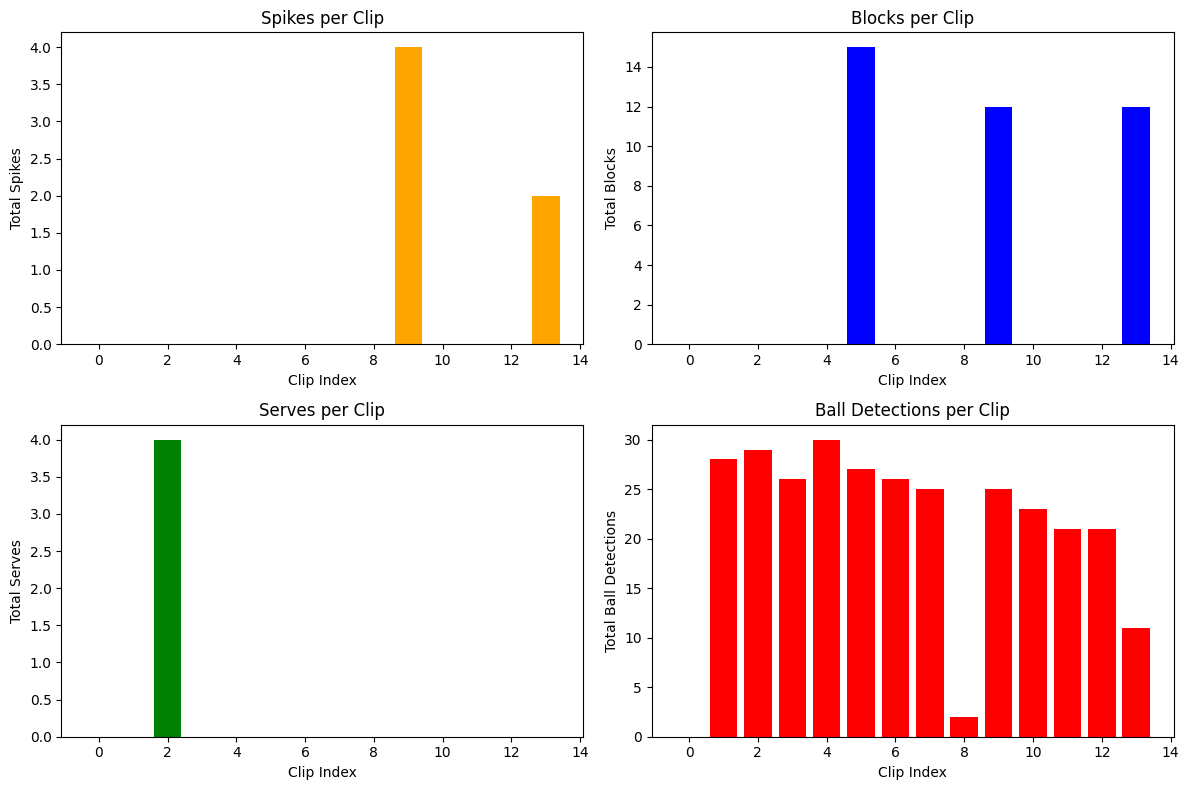

✅ API request successful.

🔍 **Volleyball Coaching Report**


Analyzing the given clips, here are key observations and coaching advice:

📌 1. Blocks are notably high in clips 5 (15 blocks), 9 (12 blocks), and 13 (12 blocks), indicating strong defensive net presence. This is excellent for disrupting opponent's attacks.

📌 2. Spikes appear only in clips 9 (4 spikes) and 13 (2 spikes), suggesting offensive attack opportunities are limited or very specific in timing.

📌 3. Serves occur only in clip 2 (4 serves), which might mean serving is concentrated or under-utilized in overall match rhythm.

📌 4. The number of balls recorded varies widely, no spikes recorded before 9s, and blocks are clustered at certain intervals, potentially implying momentum swings or shifts in tactics.

Coaching Advice:
  - Maintain and further develop the strong blocking skills seen in clips 5, 9, and 13. Work on quick repositioning after blocks to transition into attack faster.
  - Increase spike opportunities by

In [27]:
import csv
import requests
import matplotlib.pyplot as plt
import pandas as pd

API_URL = "https://api.turboline.ai/coreai/deployments/model-router/chat/completions?api-version=2025-01-01-preview"
API_KEY = "55c0d2482344472da8ef0d9a68e51d6d"

# -------- CSV parsing and preparation --------
def csv_to_text_and_dataframe(csv_path):
    lines = []
    rows = []
    with open(csv_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            lines.append(
                f"Clip {row['clip_index']} ({row['clip_label']}): "
                f"Spikes={row['total_spikes']}, Blocks={row['total_blocks']}, "
                f"Serves={row['total_serves']}, Balls={row['total_ball_detections']}, "
                f"Players={row['total_players_detected']}, "
                f"Time={float(row['clip_start_time_sec']):.1f}s-{float(row['clip_end_time_sec']):.1f}s"
            )
            rows.append(row)
    return "\n".join(lines), pd.DataFrame(rows)

# --------- Graph generation ---------
def plot_clip_stats(df):
    df['clip_index'] = df['clip_index'].astype(int)
    df['total_spikes'] = df['total_spikes'].astype(int)
    df['total_blocks'] = df['total_blocks'].astype(int)
    df['total_serves'] = df['total_serves'].astype(int)
    df['total_ball_detections'] = df['total_ball_detections'].astype(int)

    plt.figure(figsize=(12, 8))

    # Spikes
    plt.subplot(2, 2, 1)
    plt.bar(df['clip_index'], df['total_spikes'], color='orange')
    plt.title('Spikes per Clip')
    plt.xlabel('Clip Index')
    plt.ylabel('Total Spikes')

    # Blocks
    plt.subplot(2, 2, 2)
    plt.bar(df['clip_index'], df['total_blocks'], color='blue')
    plt.title('Blocks per Clip')
    plt.xlabel('Clip Index')
    plt.ylabel('Total Blocks')

    # Serves
    plt.subplot(2, 2, 3)
    plt.bar(df['clip_index'], df['total_serves'], color='green')
    plt.title('Serves per Clip')
    plt.xlabel('Clip Index')
    plt.ylabel('Total Serves')

    # Balls
    plt.subplot(2, 2, 4)
    plt.bar(df['clip_index'], df['total_ball_detections'], color='red')
    plt.title('Ball Detections per Clip')
    plt.xlabel('Clip Index')
    plt.ylabel('Total Ball Detections')

    plt.tight_layout()
    plt.show()

# ---------- Format readable response ---------
def format_api_response(api_response):
    try:
        message = api_response['choices'][0]['message']['content']
        print("\n🔍 **Volleyball Coaching Report**\n")
        for line in message.split("\n"):
            line = line.strip()
            if line.startswith(("1.", "2.", "3.", "4.")):
                print(f"\n📌 {line}")
            elif line.startswith("-"):
                print(f"  - {line[1:].strip()}")
            elif line:
                print(f"\n{line}")
    except Exception as e:
        print("❌ Failed to format response:", str(e))

# --------- Main function ---------
def send_stats_csv_for_analysis(csv_path):
    stats_text, df = csv_to_text_and_dataframe(csv_path)
    plot_clip_stats(df)

    user_message = (
        f"Here are the volleyball match stats by clips:\n\n{stats_text}\n\n"
        "Please analyze and provide coaching advice."
    )

    headers = {
        "Content-Type": "application/json",
        "Cache-Control": "no-cache",
        "tl-key": API_KEY,
    }

    data = {
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a professional volleyball coach and sports analyst assistant. "
                    "You understand volleyball game mechanics, rules, and statistics like spikes, blocks, serves, "
                    "ball possession, player positioning, and match flow. Your job is to analyze volleyball clip stats, "
                    "provide actionable coaching advice, tactical insights, and player performance feedback. Be clear, concise, and supportive."
                )
            },
            {
                "role": "user",
                "content": user_message
            }
        ],
        "max_tokens": 1000
    }

    response = requests.post(API_URL, headers=headers, json=data)
    if response.status_code == 200:
        print("✅ API request successful.")
        format_api_response(response.json())
    else:
        print("❌ API Error:", response.status_code, response.text)

# -------- Run --------
send_stats_csv_for_analysis("volleyball_clip_stats.csv")
